In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

import sys
sys.path.append('../../')
import src.fda.kde.estimators           as kde
import src.fda.plots                    as fplt
import src.fda.utils                    as fdaUtils
import src.fda.transformations.lqdt     as lqdt
import src.forecasting.pipelines        as fc
import src.forecasting.cross_validation as crossVal
import src.forecasting.accuracy         as acc

In [2]:
# Data
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_returns = pd.read_excel(returns_path, index_col="time")

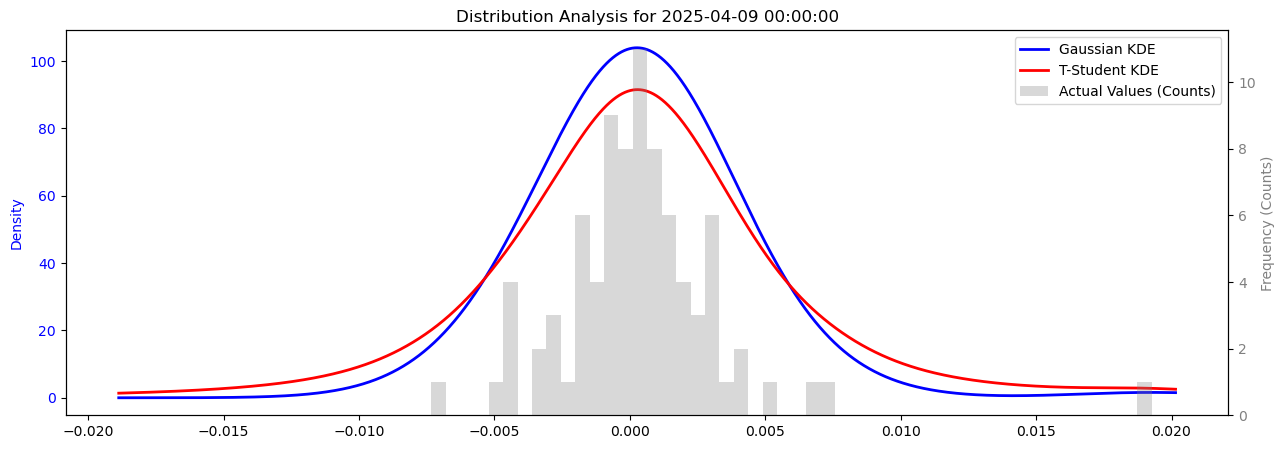

In [4]:
df_test = df_returns.copy()

df_h = df_test.copy()
df_h.iloc[:] = 0.003

df_support_n, df_densities_n = kde.df_to_kde(X=df_test, h=df_h, kernel="gaussian", normalize_densities=False)
df_support_t, df_densities_t = kde.df_to_kde(X=df_test, h=df_h, kernel="t-student", df=2, normalize_densities=False)


import matplotlib.pyplot as plt

i = 85
t = df_returns.columns[i]

fig, ax1 = plt.subplots(figsize=(15, 5))

# --- Plot KDEs on the Primary Axis (Left) ---
ax1.plot(df_support_n.loc[:, t], df_densities_n.loc[:, t], label="Gaussian KDE", color='blue', lw=2)
ax1.plot(df_support_t.loc[:, t], df_densities_t.loc[:, t], label="T-Student KDE", color='red', lw=2)
ax1.set_ylabel('Density', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- Create Secondary Axis for Histogram (Right) ---
ax2 = ax1.twinx()  
ax2.hist(df_test[t], bins=50, alpha=0.3, color='gray', label="Actual Values (Counts)")
ax2.set_ylabel('Frequency (Counts)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title(f"Distribution Analysis for {t}")
plt.show()